# LABORATORIO DIRIGIDO Nro. 05
## Semana 5: Python, Pandas, normalización y EDA básico

**Curso:** Fundamentos de Gestión de Datos
**Docente:** Pilar Rocío Sayán Mejía
**Modalidad:** Individual
**Nombre del estudiante:** Salazar Arece, Katehrine Rosmery
**Sección:** A
**Fecha:**08/06/26

### Caso de negocio

Abarrotes Esperanza cuenta con una base SQLite de ventas. La base se entrega inicialmente con una sola tabla llamada `ventas_original`, donde se repiten datos de clientes, productos y tiendas.

En este laboratorio primero se explora la tabla desnormalizada, luego se construyen tablas normalizadas con Pandas y SQLite, y finalmente se realiza un EDA básico sobre la información ya organizada.

### Fundamento teórico

| Nro. | Concepto / Principio | Definición aplicada al caso |
| --- | --- | --- |
| 1 | Tabla desnormalizada | Tabla donde se mezclan datos de ventas, clientes, productos y tiendas. |
| 2 | Normalización | Proceso de separar datos repetidos en tablas relacionadas. |
| 3 | Clave primaria | Identificador único de una tabla, como `id_cliente` o `id_producto`. |
| 4 | Clave foránea | Campo que conecta una venta con su cliente, producto o tienda. |
| 5 | DataFrame | Tabla de datos en Pandas. |
| 6 | EDA | Exploración inicial para entender estructura, nulos, duplicados y patrones. |

## Actividad 1: Carga de la base desnormalizada

Vamos a descargar desde GitHub una base SQLite que contiene la tabla `ventas_original`. Esta tabla aún no está normalizada.

In [1]:
# Paso 1: cargar librerías, descargar la base y leer la tabla original
from pathlib import Path
import urllib.request
import sqlite3
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ModuleNotFoundError:
    plt = None
    sns = None
    print("Aviso: matplotlib/seaborn no están disponibles. Se omitirán los gráficos.")

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option("display.max_columns", None)

url = "https://raw.githubusercontent.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos/main/casos/16_abarrotes_ventas_inventario/abarrotes_ventas_inventario.db"
db_path = Path("abarrotes_ventas_inventario.db")

# Descarga compatible con Google Colab y con cualquier PC (no depende de curl).
# Se descarga siempre para evitar usar una copia antigua guardada en la carpeta.
urllib.request.urlretrieve(url, db_path)

conn = sqlite3.connect(db_path)

ventas_original = pd.read_sql_query("SELECT * FROM ventas_original;", conn)

print("Tabla original cargada:", ventas_original.shape)
display(ventas_original.head(5))

Tabla original cargada: (500, 27)


,id_venta,fecha_operacion,cantidad_unidades,precio_venta_unitario,costo_unitario,descuento_pct,stock_inicial,stock_final,merma_unidades,canal,metodo_pago,monto_venta_soles,margen_venta_soles,observacion,tiendas_nombre,tiendas_distrito,tiendas_zona,tiendas_tipo_local,productos_nombre,productos_categoria,productos_proveedor,productos_costo_unitario,productos_precio_lista,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-01-22,67,15.06,10.04,8,82,15,0,Mostrador,Tarjeta,375.18,None,Promocion,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Cafe instantaneo,Bebidas,Cafe Sierra,9.70,14.87,Marco Quispe,Los Olivos,Vecino frecuente,27/12/2025
1,2,2026-01-04,37,9.42,5.94,8 aprox,223,186,0,WhatsApp,Efectivo,270.35,181.56,Revisar stock,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Papel higienico,Limpieza,Suave Hogar,5.76,9.30,Ana Soto,La Molina,Vecino frecuente,2025-12-11
2,3,2026-02-13,8,S/ 5.44,S/ 3.46,0,98,87,3 aprox,Mostrador,Efectivo,80.64,50.32,Revisar stock,Abarrotes Esperanza 6,Comas,Centro,ALMACEN,Lenteja 500g,Menestras,Campo Bueno,3.38,5.14,Marco Mendoza,Ate,Ocasional,2025-08-23
3,4,06/06/2026,44,"12,76",8.24,3,167,123,0,Telefono,Tarjeta,430.38,261.86,Promocion,Abarrotes Esperanza 3,Los Olivos,Norte,Almacen,Aceite vegetal 1L,Aceites,Oleo Andino,8.03,12.76,Miguel Mendoza,Callao,Familia,2025-10-24
4,5,2026-02-19,61,9.28,5.96,0,180,118,1,Mostrador,Yape,460.04,268.68,Promocion,Abarrotes Esperanza 2,La Molina,Norte,Almacen,Papel higienico,Limpieza,Suave Hogar,5.76,9.30,Camila Castillo,San Miguel,Negocio,2025-12-18


**Pregunta 1:** ¿Cuántas filas y columnas tiene `ventas_original`? ¿Por qué se considera una tabla desnormalizada?

Respuesta: La tabla ventas_original tiene 500 filas y 27 columnas. Se considera una tabla desnormalizada porque mezcla en una sola tabla información de ventas, clientes, productos, tiendas e inventario. Esto genera redundancia porque los mismos clientes, productos y tiendas aparecen repetidos en muchas ventas. Al repetir información, aumenta el riesgo de errores, inconsistencias y dificultad para mantener los datos actualizados.

## Actividad 2: Exploración inicial de la tabla original

Antes de normalizar, observamos columnas, tipos de datos y valores faltantes.

In [2]:
# Paso 2: revisar estructura de la tabla original
ventas_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_venta                  500 non-null    int64  
 1   fecha_operacion           486 non-null    object 
 2   cantidad_unidades         485 non-null    object 
 3   precio_venta_unitario     491 non-null    object 
 4   costo_unitario            491 non-null    object 
 5   descuento_pct             486 non-null    object 
 6   stock_inicial             489 non-null    object 
 7   stock_final               483 non-null    object 
 8   merma_unidades            491 non-null    object 
 9   canal                     485 non-null    object 
 10  metodo_pago               477 non-null    object 
 11  monto_venta_soles         487 non-null    object 
 12  margen_venta_soles        488 non-null    object 
 13  observacion               459 non-null    object 
 14  tiendas_no

In [3]:
nulos_original = ventas_original.isna().sum().sort_values(ascending=False)
print("\nColumnas con más nulos:")
display(nulos_original.head(10))



Columnas con más nulos:


,0
observacion,41
metodo_pago,23
stock_final,17
clientes_nombre,17
clientes_segmento,16
canal,15
cantidad_unidades,15
descuento_pct,14
fecha_operacion,14
monto_venta_soles,13


**Pregunta 2:** ¿Qué grupos de datos se mezclan en `ventas_original`? Piensa en ventas, clientes, productos y tiendas.

Respuesta: En ventas_original se mezclan varios grupos de datos. Están los datos de ventas, como id_venta, fecha_operacion, canal, metodo_pago, cantidad_unidades, monto_venta_soles y margen_venta_soles. También hay datos de clientes, como clientes_nombre, clientes_distrito y clientes_segmento. Además, se incluyen datos de productos, como productos_nombre, productos_categoria y productos_proveedor. Finalmente, aparecen datos de tiendas e inventario, como tiendas_nombre, tiendas_distrito, tiendas_zona, stock_inicial, stock_final y merma_unidades.

## Actividad 3: Identificación de datos repetidos

La normalización se justifica cuando la misma información aparece repetida muchas veces.

In [4]:
# Paso 3: medir repetición de clientes, productos y tiendas
clientes_repetidos = (
    ventas_original
    .groupby(["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

productos_repetidos = (
    ventas_original
    .groupby(["productos_nombre", "productos_categoria", "productos_proveedor"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

tiendas_repetidas = (
    ventas_original
    .groupby(["tiendas_nombre", "tiendas_distrito", "tiendas_zona"])
    .size()
    .reset_index(name="veces_repetido")
    .sort_values("veces_repetido", ascending=False)
)

print("Clientes repetidos")
display(clientes_repetidos.head(8))
print("Productos repetidos")
display(productos_repetidos.head(8))
print("Tiendas repetidas")
display(tiendas_repetidas.head(8))


Clientes repetidos


,clientes_nombre,clientes_distrito,clientes_segmento,veces_repetido
56,Marco Huaman,San Miguel,Vecino frecuente,12
3,Ana Flores,San Juan de Lurigancho,Ocasional,10
11,Andre Rojas,Comas,Familia,10
14,Camila Campos,San Miguel,Ocasional,10
0,Maria Reyes,Los Olivos,Ocasional,10
51,Luis Quispe,Ventanilla,Negocio,10
60,Maria Ramos,Los Olivos,Vecino frecuente,9
17,Camila Quispe,Surco,Negocio,8


Productos repetidos


,productos_nombre,productos_categoria,productos_proveedor,veces_repetido
11,galletas soda,Snacks,Dulcesur,46
4,Cafe instantaneo,Bebidas,Cafe Sierra,46
0,Aceite vegetal 1L,Aceites,Oleo Andino,45
1,Arroz extra 5kg,granos,Molino Norte,45
3,Azucar rubia 1kg,Endulzantes,Dulce Peru,44
2,Atun en lata,Conservas,Mar Azul,43
9,Papel higienico,Limpieza,Suave Hogar,43
6,Fideos spaghetti,Pastas,Pastas Sol,43


Tiendas repetidas


,tiendas_nombre,tiendas_distrito,tiendas_zona,veces_repetido
5,Abarrotes Esperanza 6,Comas,Centro,83
3,Abarrotes Esperanza 4,Miraflores,Norte,81
2,Abarrotes Esperanza 3,Los Olivos,Norte,77
0,Abarrotes Esperanza 1,Los Olivos,Sur,72
1,Abarrotes Esperanza 2,La Molina,Norte,66
6,Abarrotes Esperanza 7,La Molina,Sur,61
4,Abarrotes Esperanza 5,La Molina,Este,60


**Pregunta 3:** ¿Qué información conviene separar en tablas independientes? Sustenta usando las repeticiones observadas.

Respuesta: Conviene separar la información en tablas independientes de clientes, productos, categorías, tiendas y ventas. Esto se justifica porque en la exploración se observaron repeticiones importantes. Por ejemplo, algunos clientes aparecen varias veces, productos como galletas soda y Cafe instantaneo aparecen 46 veces, y tiendas como Abarrotes Esperanza 6 aparecen 83 veces. Separar estos datos evita repetir la misma información en cada venta y permite tener una base más ordenada, limpia y fácil de mantener.

## Actividad 4: Limpieza mínima antes de normalizar

Antes de crear las tablas, limpiamos espacios, formatos de texto, fechas y columnas numéricas necesarias.

In [5]:
# Paso 4: preparar una copia limpia para normalizar y analizar
ventas_limpia = ventas_original.copy()

columnas_texto = [
    "canal", "metodo_pago", "observacion",
    "tiendas_nombre", "tiendas_distrito", "tiendas_zona", "tiendas_tipo_local",
    "productos_nombre", "productos_categoria", "productos_proveedor",
    "clientes_nombre", "clientes_distrito", "clientes_segmento"
]

for col in columnas_texto:
    ventas_limpia[col] = (
        ventas_limpia[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

columnas_numericas = [
    "cantidad_unidades", "precio_venta_unitario", "costo_unitario", "descuento_pct",
    "stock_inicial", "stock_final", "merma_unidades",
    "monto_venta_soles", "margen_venta_soles",
    "productos_costo_unitario", "productos_precio_lista"
]

for col in columnas_numericas:
    texto = (
        ventas_limpia[col]
        .astype("string")
        .str.replace("S/", "", regex=False)
        .str.replace("aprox", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    ventas_limpia[col] = pd.to_numeric(texto, errors="coerce")

ventas_limpia["fecha_operacion"] = pd.to_datetime(ventas_limpia["fecha_operacion"], errors="coerce")
ventas_limpia["clientes_fecha_registro"] = pd.to_datetime(
    ventas_limpia["clientes_fecha_registro"],
    errors="coerce",
    dayfirst=True
)

display(ventas_limpia.head(5))


,id_venta,fecha_operacion,cantidad_unidades,precio_venta_unitario,costo_unitario,descuento_pct,stock_inicial,stock_final,merma_unidades,canal,metodo_pago,monto_venta_soles,margen_venta_soles,observacion,tiendas_nombre,tiendas_distrito,tiendas_zona,tiendas_tipo_local,productos_nombre,productos_categoria,productos_proveedor,productos_costo_unitario,productos_precio_lista,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-01-22,67,15.06,10.04,8,82,15,0,Mostrador,Tarjeta,375.18,<NA>,Promocion,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Cafe instantaneo,Bebidas,Cafe Sierra,9.7,14.87,Marco Quispe,Los Olivos,Vecino frecuente,2025-12-27
1,2,2026-01-04,37,9.42,5.94,8,223,186,0,WhatsApp,Efectivo,270.35,181.56,Revisar stock,Abarrotes Esperanza 4,Miraflores,Norte,Tienda de mercado,Papel higienico,Limpieza,Suave Hogar,5.76,9.3,Ana Soto,La Molina,Vecino frecuente,NaT
2,3,2026-02-13,8,5.44,3.46,0,98,87,3,Mostrador,Efectivo,80.64,50.32,Revisar stock,Abarrotes Esperanza 6,Comas,Centro,ALMACEN,Lenteja 500g,Menestras,Campo Bueno,3.38,5.14,Marco Mendoza,Ate,Ocasional,NaT
3,4,NaT,44,12.76,8.24,3,167,123,0,Telefono,Tarjeta,430.38,261.86,Promocion,Abarrotes Esperanza 3,Los Olivos,Norte,Almacen,Aceite vegetal 1L,Aceites,Oleo Andino,8.03,12.76,Miguel Mendoza,Callao,Familia,NaT
4,5,2026-02-19,61,9.28,5.96,0,180,118,1,Mostrador,Yape,460.04,268.68,Promocion,Abarrotes Esperanza 2,La Molina,Norte,Almacen,Papel higienico,Limpieza,Suave Hogar,5.76,9.3,Camila Castillo,San Miguel,Negocio,NaT


**Pregunta 4:** ¿Qué columnas tuvieron que convertirse a numéricas o fechas? ¿Por qué no conviene hacer EDA antes de esta limpieza?

Respuesta: Se convirtieron a numéricas columnas como cantidad_unidades, precio_venta_unitario, costo_unitario, descuento_pct, stock_inicial, stock_final, merma_unidades, monto_venta_soles, margen_venta_soles, productos_costo_unitario y productos_precio_lista. También se convirtieron a fecha fecha_operacion y clientes_fecha_registro. No conviene hacer EDA antes de esta limpieza porque algunas columnas tenían valores como S/, comas decimales o la palabra aprox. Si no se limpian, Pandas puede interpretar números como texto y los cálculos de promedios, máximos, mínimos, gráficos y correlaciones saldrían incorrectos.

## Actividad 5: Construcción de tablas normalizadas

A partir de `ventas_limpia`, construiremos tablas separadas: `clientes`, `categorias`, `productos`, `tiendas` y `ventas`.

In [6]:
# Paso 5: crear tablas normalizadas con Pandas
categorias = (
    ventas_limpia[["productos_categoria"]]
    .drop_duplicates()
    .sort_values("productos_categoria")
    .reset_index(drop=True)
    .rename(columns={"productos_categoria": "categoria"})
)
categorias.insert(0, "id_categoria", range(1, len(categorias) + 1))

productos = (
    ventas_limpia[["productos_nombre", "productos_categoria", "productos_proveedor", "productos_costo_unitario", "productos_precio_lista"]]
    .drop_duplicates(subset=["productos_nombre", "productos_categoria", "productos_proveedor"])
    .sort_values("productos_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "productos_nombre": "producto",
        "productos_categoria": "categoria",
        "productos_proveedor": "proveedor",
        "productos_costo_unitario": "costo_unitario",
        "productos_precio_lista": "precio_lista"
    })
)
productos = productos.merge(categorias, on="categoria", how="left")
productos.insert(0, "id_producto", range(1, len(productos) + 1))
productos = productos[["id_producto", "producto", "id_categoria", "proveedor", "costo_unitario", "precio_lista"]]

clientes = (
    ventas_limpia[["clientes_nombre", "clientes_distrito", "clientes_segmento", "clientes_fecha_registro"]]
    .drop_duplicates(subset=["clientes_nombre", "clientes_distrito", "clientes_segmento"])
    .sort_values("clientes_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "clientes_nombre": "cliente",
        "clientes_distrito": "distrito_cliente",
        "clientes_segmento": "segmento_cliente",
        "clientes_fecha_registro": "fecha_registro"
    })
)
clientes.insert(0, "id_cliente", range(1, len(clientes) + 1))

tiendas = (
    ventas_limpia[["tiendas_nombre", "tiendas_distrito", "tiendas_zona", "tiendas_tipo_local"]]
    .drop_duplicates(subset=["tiendas_nombre", "tiendas_distrito", "tiendas_zona"])
    .sort_values("tiendas_nombre")
    .reset_index(drop=True)
    .rename(columns={
        "tiendas_nombre": "tienda",
        "tiendas_distrito": "distrito_tienda",
        "tiendas_zona": "zona",
        "tiendas_tipo_local": "tipo_local"
    })
)
tiendas.insert(0, "id_tienda", range(1, len(tiendas) + 1))

print("categorias:", categorias.shape)
print("productos:", productos.shape)
print("clientes:", clientes.shape)
print("tiendas:", tiendas.shape)

display(productos.head())


categorias: (10, 2)
productos: (12, 6)
clientes: (90, 5)
tiendas: (7, 5)


,id_producto,producto,id_categoria,proveedor,costo_unitario,precio_lista
0,1,Aceite vegetal 1L,1,Oleo Andino,8.03,12.76
1,2,Arroz extra 5kg,10,Molino Norte,18.95,27.3
2,3,Atun en lata,3,Mar Azul,4.39,6.74
3,4,Azucar rubia 1kg,4,Dulce Peru,3.35,4.79
4,5,Cafe instantaneo,2,Cafe Sierra,9.7,14.87


**Pregunta 5:** ¿Qué columna funciona como clave primaria en cada tabla creada? ¿Qué datos repetidos dejó de tener la tabla de ventas?

Respuesta: Las claves primarias son: id_categoria en la tabla categorias, id_producto en productos, id_cliente en clientes, id_tienda en tiendas e id_venta en ventas. La tabla ventas dejó de tener datos repetidos como nombres de clientes, distritos, segmentos, nombres de productos, categorías, proveedores, nombres de tiendas y zonas. Esos datos fueron reemplazados por identificadores como id_cliente, id_producto e id_tienda.

## Actividad 6: Crear la tabla de ventas con claves

La nueva tabla `ventas` conserva datos propios de la operación y reemplaza textos repetidos por códigos.

In [7]:
# Paso 6: construir la tabla de ventas normalizada
ventas = ventas_limpia.merge(
    clientes[["id_cliente", "cliente", "distrito_cliente", "segmento_cliente"]],
    left_on=["clientes_nombre", "clientes_distrito", "clientes_segmento"],
    right_on=["cliente", "distrito_cliente", "segmento_cliente"],
    how="left"
)

ventas = ventas.merge(
    productos[["id_producto", "producto"]],
    left_on="productos_nombre",
    right_on="producto",
    how="left"
)

ventas = ventas.merge(
    tiendas[["id_tienda", "tienda", "distrito_tienda", "zona"]],
    left_on=["tiendas_nombre", "tiendas_distrito", "tiendas_zona"],
    right_on=["tienda", "distrito_tienda", "zona"],
    how="left"
)

ventas = ventas[[
    "id_venta", "fecha_operacion", "id_cliente", "id_producto", "id_tienda",
    "cantidad_unidades", "precio_venta_unitario", "costo_unitario", "descuento_pct",
    "stock_inicial", "stock_final", "merma_unidades", "canal", "metodo_pago",
    "monto_venta_soles", "margen_venta_soles"
]].copy()

display(ventas.head(8))
print("ventas normalizada:", ventas.shape)


,id_venta,fecha_operacion,id_cliente,id_producto,id_tienda,cantidad_unidades,precio_venta_unitario,costo_unitario,descuento_pct,stock_inicial,stock_final,merma_unidades,canal,metodo_pago,monto_venta_soles,margen_venta_soles
0,1,2026-01-22,61,5,4,67,15.06,10.04,8,82,15,0,Mostrador,Tarjeta,375.18,<NA>
1,2,2026-01-04,6,10,4,37,9.42,5.94,8,223,186,0,WhatsApp,Efectivo,270.35,181.56
2,3,2026-02-13,60,9,6,8,5.44,3.46,0,98,87,3,Mostrador,Efectivo,80.64,50.32
3,4,NaT,65,1,3,44,12.76,8.24,3,167,123,0,Telefono,Tarjeta,430.38,261.86
4,5,2026-02-19,15,10,2,61,9.28,5.96,0,180,118,1,Mostrador,Yape,460.04,268.68
5,6,2026-01-09,5,2,3,21,28.91,19.0,10,176,155,0,Mostrador,Tarjeta,198.6,-9.56
6,7,2026-01-04,71,11,6,55,7.18,4.89,10,127,72,0,WhatsApp,Efectivo,499.65,408.34
7,8,2026-01-13,29,12,3,51,2.76,1.6,3,265,214,0,WhatsApp,Efectivo,324.68,302.75


ventas normalizada: (500, 16)


**Pregunta 6:** ¿Qué columnas de texto desaparecieron de `ventas` y fueron reemplazadas por identificadores?

Respuesta: Desaparecieron de la tabla ventas columnas de texto repetidas como clientes_nombre, clientes_distrito, clientes_segmento, productos_nombre, productos_categoria, productos_proveedor, tiendas_nombre, tiendas_distrito y tiendas_zona. Estas columnas fueron reemplazadas por identificadores: id_cliente, id_producto e id_tienda. Así, la tabla ventas conserva solo los datos propios de la operación, como fecha, cantidad, precio, descuento, stock, canal, método de pago, monto y margen.

## Actividad 7: Guardar el modelo normalizado en SQLite y validar

Guardamos las nuevas tablas en la misma conexión SQLite y reconstruimos un reporte legible para comprobar que la información no se perdió.

In [8]:
# Paso 7: guardar tablas normalizadas en SQLite
categorias.to_sql("categorias", conn, if_exists="replace", index=False)
productos.to_sql("productos", conn, if_exists="replace", index=False)
clientes.to_sql("clientes", conn, if_exists="replace", index=False)
tiendas.to_sql("tiendas", conn, if_exists="replace", index=False)
ventas.to_sql("ventas", conn, if_exists="replace", index=False)

consulta_tablas = pd.read_sql_query(
    """
    SELECT name AS tabla
    FROM sqlite_schema
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
    """,
    conn
)
display(consulta_tablas)

reporte_validacion = pd.read_sql_query(
    """
    SELECT
        v.id_venta,
        v.fecha_operacion,
        c.cliente,
        p.producto,
        cat.categoria,
        t.tienda,
        v.cantidad_unidades,
        v.monto_venta_soles
    FROM ventas v
    LEFT JOIN clientes c ON v.id_cliente = c.id_cliente
    LEFT JOIN productos p ON v.id_producto = p.id_producto
    LEFT JOIN categorias cat ON p.id_categoria = cat.id_categoria
    LEFT JOIN tiendas t ON v.id_tienda = t.id_tienda
    ORDER BY v.id_venta
    LIMIT 10
    """,
    conn
)
display(reporte_validacion)


,tabla
0,categorias
1,clientes
2,productos
3,tiendas
4,ventas
5,ventas_original


,id_venta,fecha_operacion,cliente,producto,categoria,tienda,cantidad_unidades,monto_venta_soles
0,1,2026-01-22 00:00:00,Marco Quispe,Cafe instantaneo,Bebidas,Abarrotes Esperanza 4,67,375.18
1,2,2026-01-04 00:00:00,Ana Soto,Papel higienico,Limpieza,Abarrotes Esperanza 4,37,270.35
2,3,2026-02-13 00:00:00,Marco Mendoza,Lenteja 500g,Menestras,Abarrotes Esperanza 6,8,80.64
3,4,None,Miguel Mendoza,Aceite vegetal 1L,Aceites,Abarrotes Esperanza 3,44,430.38
4,5,2026-02-19 00:00:00,Camila Castillo,Papel higienico,Limpieza,Abarrotes Esperanza 2,61,460.04
5,6,2026-01-09 00:00:00,Ana Paredes,Arroz extra 5kg,granos,Abarrotes Esperanza 3,21,198.60
6,7,2026-01-04 00:00:00,Raul Rojas,Yogurt familiar,Lacteos,Abarrotes Esperanza 6,55,499.65
7,8,2026-01-13 00:00:00,Claudia Salazar,galletas soda,Snacks,Abarrotes Esperanza 3,51,324.68
8,9,2026-03-21 00:00:00,Lucia Salazar,Papel higienico,Limpieza,Abarrotes Esperanza 6,48,334.42
9,10,2026-02-13 00:00:00,Marco Mendoza,Lenteja 500g,Menestras,Abarrotes Esperanza 6,8,80.64


**Pregunta 7:** ¿Por qué se necesita `JOIN` después de normalizar? ¿Qué confirma el reporte de validación?

Respuesta: Después de normalizar se necesita usar JOIN porque la información ya no está en una sola tabla. Ahora los datos están separados en ventas, clientes, productos, categorias y tiendas. El JOIN permite volver a unir esas tablas mediante sus identificadores para construir un reporte completo y legible. El reporte de validación confirma que la información no se perdió, porque se puede volver a visualizar cada venta con su cliente, producto, categoría, tienda, cantidad y monto de venta.

## Actividad 8: EDA descriptivo sobre la tabla ventas normalizada

Ahora que la base está organizada, analizamos variables numéricas de ventas.

In [9]:
# Paso 8: estadística descriptiva sobre ventas normalizadas
columnas_eda = [
    "cantidad_unidades",
    "precio_venta_unitario",
    "monto_venta_soles",
    "margen_venta_soles",
    "stock_final"
]

resumen_descriptivo = ventas[columnas_eda].describe()
display(resumen_descriptivo)

nulos = ventas.isna().sum().sort_values(ascending=False)
duplicados = ventas.duplicated().sum()
print("Filas duplicadas en ventas:", duplicados)
display(nulos.head(10))


,cantidad_unidades,precio_venta_unitario,monto_venta_soles,margen_venta_soles,stock_final
count,485.0,491.0,487.0,488.0,483.0
mean,42.65567,9.438208,319.399261,185.158361,123.093168
std,29.420768,6.763202,236.28869,172.214891,66.339764
min,4.0,2.68,13.63,-210.13,8.0
25%,22.0,4.98,168.485,63.185,67.0
50%,42.0,7.18,288.89,162.34,124.0
75%,60.0,12.53,427.755,284.3525,178.5
max,290.0,29.46,2493.24,1369.91,245.0


Filas duplicadas en ventas: 0


,0
fecha_operacion,81
metodo_pago,23
stock_final,17
cantidad_unidades,15
canal,15
descuento_pct,14
monto_venta_soles,13
margen_venta_soles,12
stock_inicial,11
precio_venta_unitario,9


**Pregunta 8:** Según `describe()`, ¿qué variable tiene mayor dispersión? ¿Hay nulos relevantes después de normalizar?

Respuesta: Según describe(), la variable con mayor dispersión es monto_venta_soles, porque tiene una desviación estándar aproximada de 236.29, mayor que las demás variables analizadas. Esto indica que los montos de venta varían bastante entre registros. Después de normalizar todavía existen nulos relevantes, por ejemplo en fecha_operacion, metodo_pago, stock_final, cantidad_unidades, canal, descuento_pct, monto_venta_soles y margen_venta_soles. Sin embargo, no hay filas duplicadas en la tabla ventas, ya que el resultado muestra 0 duplicados.

## Actividad 9: Gráficos básicos

Graficamos la distribución del monto de venta y el monto acumulado por categoría.

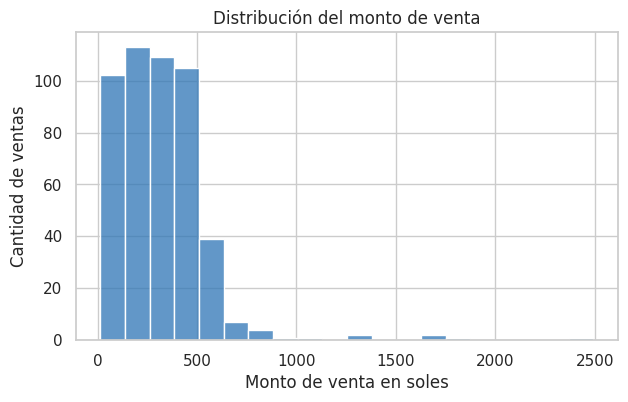

,categoria,monto_venta_soles
0,Limpieza,27006.35
1,Lacteos,21782.2
2,granos,18371.24
3,Aceites,15511.08
4,Bebidas,14065.01
5,Conservas,13362.34
6,Snacks,13305.92
7,Pastas,11826.49
8,Endulzantes,11751.7
9,Menestras,8565.11


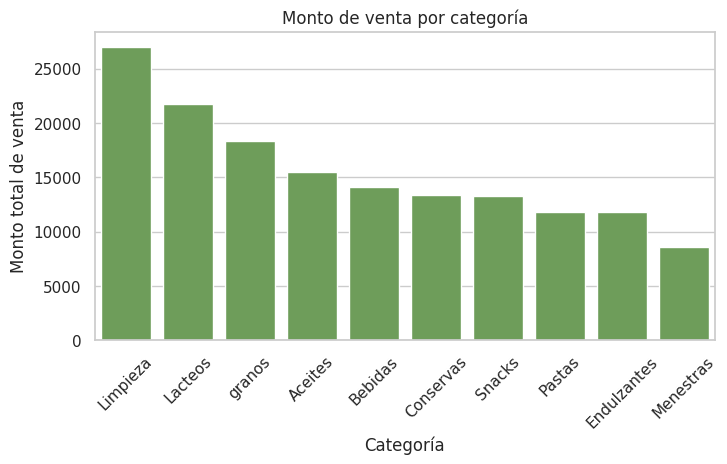

In [10]:
# Paso 9: histograma y barras por categoría
if plt is not None and sns is not None:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=ventas, x="monto_venta_soles", bins=20, color="#2E75B6")
    plt.title("Distribución del monto de venta")
    plt.xlabel("Monto de venta en soles")
    plt.ylabel("Cantidad de ventas")
    plt.show()
else:
    print("Gráfico omitido porque matplotlib/seaborn no están disponibles.")

ventas_categoria = (
    ventas[["id_producto", "monto_venta_soles"]]
    .merge(productos[["id_producto", "id_categoria"]], on="id_producto", how="left")
    .merge(categorias, on="id_categoria", how="left")
)

ventas_por_categoria = (
    ventas_categoria
    .groupby("categoria")["monto_venta_soles"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(ventas_por_categoria)

if plt is not None and sns is not None:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=ventas_por_categoria, x="categoria", y="monto_venta_soles", color="#6AA84F")
    plt.title("Monto de venta por categoría")
    plt.xlabel("Categoría")
    plt.ylabel("Monto total de venta")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Gráfico omitido porque matplotlib/seaborn no están disponibles.")


**Pregunta 9:** ¿En qué rango se concentran más ventas? ¿Qué categoría tiene mayor monto total de venta?

Respuesta: Las ventas se concentran principalmente en montos bajos y medios. Según los percentiles, el 50% de las ventas está por debajo de aproximadamente S/ 288.89 y el 75% está por debajo de aproximadamente S/ 427.76. Por eso, la mayor parte de ventas se ubica aproximadamente entre S/ 168 y S/ 428. La categoría con mayor monto total de venta es Limpieza, con aproximadamente S/ 27,006.35, por lo que esta categoría representa una oportunidad importante para el negocio.

## Actividad 10: Correlación sencilla y cierre

Revisamos una matriz de correlación con variables numéricas clave.

,cantidad_unidades,precio_venta_unitario,monto_venta_soles,margen_venta_soles
cantidad_unidades,1.000000,0.093698,0.877329,0.598663
precio_venta_unitario,0.093698,1.000000,0.145693,-0.491894
monto_venta_soles,0.877329,0.145693,1.000000,0.650695
margen_venta_soles,0.598663,-0.491894,0.650695,1.000000


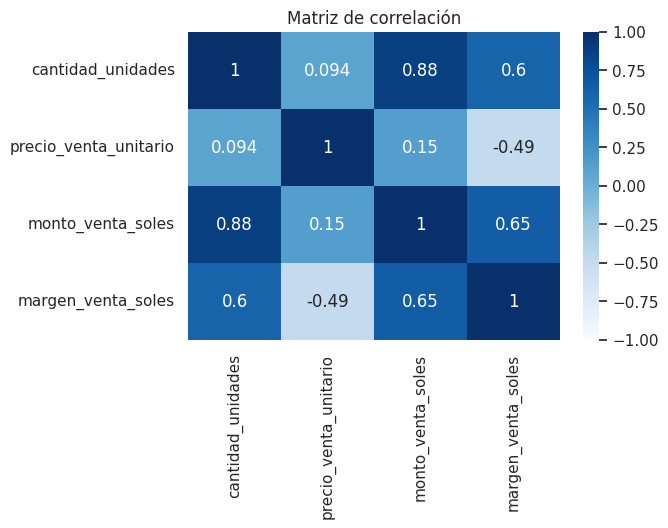

In [11]:
# Paso 10: matriz de correlación
matriz_correlacion = ventas[[
    "cantidad_unidades",
    "precio_venta_unitario",
    "monto_venta_soles",
    "margen_venta_soles"
]].corr()

display(matriz_correlacion)

if plt is not None and sns is not None:
    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz_correlacion, annot=True, cmap="Blues", vmin=-1, vmax=1)
    plt.title("Matriz de correlación")
    plt.show()
else:
    print("Mapa de calor omitido porque matplotlib/seaborn no están disponibles.")


**Pregunta 10:** Escribe tres conclusiones breves: una sobre normalización, una sobre calidad de datos y una sobre el EDA.

Respuesta: La normalización permitió organizar mejor la información al separar clientes, productos, categorías, tiendas y ventas en tablas independientes. En calidad de datos, se encontraron valores nulos, fechas inválidas y columnas numéricas almacenadas como texto, por lo que fue necesario limpiar antes de analizar. En el EDA se identificó que la categoría Limpieza tuvo el mayor monto acumulado de ventas y que existe una correlación fuerte entre cantidad_unidades y monto_venta_soles. Esto permite tomar decisiones comerciales basadas en evidencia.

| N° | Conclusión técnica                                                                                                                                                                                                                                                                                  |
| -- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1  | La tabla `ventas_original` estaba desnormalizada porque reunía datos de ventas, clientes, productos, tiendas e inventario en una sola estructura. Al separar la información en tablas independientes con claves primarias, se redujo la redundancia y se mejoró la integridad de los datos.         |
| 2  | La limpieza de datos fue necesaria porque varias columnas numéricas estaban como texto y algunas fechas no tenían formato correcto. El uso de `pd.to_numeric()` y `pd.to_datetime()` permitió preparar los datos para estadísticas descriptivas, gráficos y correlaciones confiables.               |
| 3  | El EDA permitió encontrar patrones útiles para el negocio. La categoría `Limpieza` tuvo el mayor monto acumulado de ventas y la correlación entre `cantidad_unidades` y `monto_venta_soles` fue fuerte, por lo que el negocio podría priorizar stock y promociones en categorías de mayor rotación. |


## MATERIAL COMPLEMENTARIO

- Repositorio PMD1: https://github.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos
- Pandas documentation: https://pandas.pydata.org/docs/
- Seaborn documentation: https://seaborn.pydata.org/